# Logistic Regression with Feature Engineering

In [134]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_fscore_support,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

sys.path.append(str(Path("..").resolve()))
from transcript_preprocessing import get_stratified_kfold_splits
from utils import compute_linguistic_features_for_column

DATA_PATH = Path("..") / "data" / "transcripts_cleaned.csv"
DEMENTIA_PATH = Path("..") / "data" / "dementia_data.csv"



## Load Data

Load the cleaned transcripts and check the class distribution


In [135]:
# Load data
transcript_df = pd.read_csv(DATA_PATH)
dementia_df = pd.read_csv(DEMENTIA_PATH)


print(f"Class distribution:")
print(transcript_df["Class"].value_counts())



Class distribution:
Class
HC          82
MCI         59
Dementia    16
Name: count, dtype: int64


## Feature Engineering

linguistic and demographic features

**Linguistic Features:**
| Feature | Description |
|---------|-------------|
| `token_count` | Total number of words |
| `type_count` | Number of unique words |
| `type_token_ratio` | Vocabulary diversity (unique/total) |
| `brunets_index` | Lexical richness measure |
| `ma_ttr` | Moving-average type-token ratio |
| `sentence_count` | Number of sentences |
| `average_words_per_sentence` | Mean sentence length |
| `filler_count` | Count of filler words (um, uh, er, etc.) |
| `found_fillers` | Binary: has any filler words? |
| `content_density` | Proportion of content words |
| `repetitions` | Number of repeated words |

**Demographic Features:**
| Feature | Description |
|---------|-------------|
| `Gender` | Encoded as 0/1 |
| `Age` | Patient age |
| `Converted-MMSE` | Mini-Mental State Exam score |


In [136]:
features_by_transcript = {}

for col in TRANSCRIPT_COLS:
    df = transcript_df.dropna(subset=[col]).copy()
    
    df_with_features = compute_linguistic_features_for_column(df, col)
    features_by_transcript[col] = df_with_features
    
    print(f"{col}: {len(df_with_features)} samples")

# demographic features
demo_df = dementia_df[["Record-ID", "Gender", "Age", "Converted-MMSE"]].copy()

# clean demographic data 
demo_df["Gender"] = demo_df["Gender"].map({"female": 0, "male": 1})
demo_df["Age"] = pd.to_numeric(demo_df["Age"].astype(str).str.replace(r"[^0-9.]", "", regex=True), errors="coerce")
demo_df["Converted-MMSE"] = pd.to_numeric(demo_df["Converted-MMSE"].astype(str).str.replace(r"[^0-9.]", "", regex=True), errors="coerce")

for col in TRANSCRIPT_COLS:
    features_by_transcript[col] = features_by_transcript[col].merge(
        demo_df, on="Record-ID", how="left"
    )


FEATURE_COLS = [
    # Linguistic features
    "token_count",
    "type_count", 
    "type_token_ratio",
    "ma_ttr",
    "brunets_index",
    "sentence_count",
    "average_words_per_sentence",
    "filler_count",
    "found_fillers",
    "content_density",
    "repetitions",
    # Demographic features
    "Gender",
    "Age",
    "Converted-MMSE",
]



Transcript_PFT: 157 samples
Transcript_CTD: 156 samples
Transcript_SFT: 152 samples


## Hyperparameter Search 

Different combinations of C (Regularization strength) and  class_weight


In [137]:
C_VALUES = [0.01, 0.1, 1.0, 10.0]
CLASS_WEIGHTS = [None, "balanced"]

#all configs to try
configs = []
for c in C_VALUES:
    for cw in CLASS_WEIGHTS:
        configs.append({"C": c, "class_weight": cw})



## Cross-Validation Function



In [138]:
def run_cv(df, transcript_col, config, n_splits=5, seed=42):
    """
    Run stratified k-fold cross-validation 
    """
    fold_results = []
    
    for fold_idx, train_idx, val_idx in get_stratified_kfold_splits(
        transcript_df=df,
        transcript_col=transcript_col,
        label_col="Label",
        n_splits=n_splits,
        seed=seed,
    ):

        X_train = df.iloc[train_idx][FEATURE_COLS].values
        y_train = df.iloc[train_idx]["Label"].values
        X_val = df.iloc[val_idx][FEATURE_COLS].values
        y_val = df.iloc[val_idx]["Label"].values
        
        X_train = np.nan_to_num(X_train, nan=0.0)
        X_val = np.nan_to_num(X_val, nan=0.0)
        
        # Scale features 
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)
        
        # Train
        model = LogisticRegression(
            C=config["C"],
            class_weight=config["class_weight"],
            max_iter=1000,
            random_state=seed,
        )
        model.fit(X_train, y_train)
        
    
        y_pred = model.predict(X_val)
        
        fold_results.append({
            "accuracy": accuracy_score(y_val, y_pred),
            "macro_f1": f1_score(y_val, y_pred, average="macro", zero_division=0),
        })
    
    # Average across folds
    return {
        "mean_accuracy": np.mean([r["accuracy"] for r in fold_results]),
        "mean_macro_f1": np.mean([r["macro_f1"] for r in fold_results]),
    }




## Run Grid Search

Try all hyperparameter combinations for each transcript type and find the best one.


In [139]:
# Run grid search for all transcript types
all_results = []
best_configs = {}

for transcript_col in TRANSCRIPT_COLS:
    df = features_by_transcript[transcript_col]
    print(f"\n{transcript_col} ({len(df)} samples)")
    
    best_f1 = 0
    best_config = None
    
    for config in configs:
        results = run_cv(df, transcript_col, config)
        
        all_results.append({
            "transcript": transcript_col,
            "C": config["C"],
            "class_weight": config["class_weight"],
            **results
        })
        
        # Track best config for this transcript type
        if results["mean_macro_f1"] > best_f1:
            best_f1 = results["mean_macro_f1"]
            best_config = config.copy()
    
    best_configs[transcript_col] = best_config
    print(f"Best: C={best_config['C']}, class_weight={best_config['class_weight']}")
    print(f"Macro F1: {best_f1:.4f}")


results_df = pd.DataFrame(all_results)




Transcript_PFT (157 samples)
Best: C=10.0, class_weight=None
Macro F1: 0.4054

Transcript_CTD (156 samples)
Best: C=0.1, class_weight=None
Macro F1: 0.4305

Transcript_SFT (152 samples)
Best: C=0.1, class_weight=balanced
Macro F1: 0.4079


In [140]:
# top 3 configs per transcript type
results_df.sort_values(
    ["transcript", "mean_macro_f1"], 
    ascending=[True, False]
).groupby("transcript").head(3)


,transcript,C,class_weight,mean_accuracy,mean_macro_f1
10,Transcript_CTD,0.10,None,0.646774,0.430488
14,Transcript_CTD,10.00,None,0.564113,0.419072
8,Transcript_CTD,0.01,None,0.633669,0.404653
6,Transcript_PFT,10.00,None,0.579234,0.405351
4,Transcript_PFT,1.00,None,0.572782,0.392045
3,Transcript_PFT,0.10,balanced,0.476613,0.389784
19,Transcript_SFT,0.10,balanced,0.480430,0.407854
23,Transcript_SFT,10.00,balanced,0.466667,0.406816
22,Transcript_SFT,10.00,None,0.526022,0.398430


## Evaluate Best Models

Generate confusion matrices and classification reports using the best hyperparameters for each transcript type.


In [141]:
CLASS_NAMES = ["HC", "MCI", "Dementia"]

def evaluate_best_model(df, transcript_col, config, n_splits=5, seed=42):
    """
    Run CV with best config and collect all predictions for confusion matrix.
    """
    all_y_true = []
    all_y_pred = []
    
    for fold_idx, train_idx, val_idx in get_stratified_kfold_splits(
        transcript_df=df, transcript_col=transcript_col,
        label_col="Label", n_splits=n_splits, seed=seed,
    ):
        X_train = np.nan_to_num(df.iloc[train_idx][FEATURE_COLS].values, nan=0.0)
        y_train = df.iloc[train_idx]["Label"].values
        X_val = np.nan_to_num(df.iloc[val_idx][FEATURE_COLS].values, nan=0.0)
        y_val = df.iloc[val_idx]["Label"].values
        
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)
        
        model = LogisticRegression(
            C=config["C"], class_weight=config["class_weight"],
            max_iter=1000, random_state=seed
        )
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        
        all_y_true.extend(y_val)
        all_y_pred.extend(y_pred)
    
    return np.array(all_y_true), np.array(all_y_pred)



### Confusion Matrices and Classification Reports


Transcript_PFT
Best config: C=10.0, class_weight=None


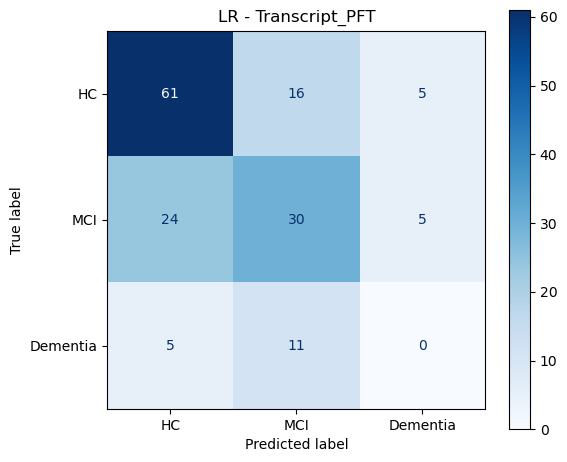


Classification Report:
              precision    recall  f1-score   support

          HC       0.68      0.74      0.71        82
         MCI       0.53      0.51      0.52        59
    Dementia       0.00      0.00      0.00        16

    accuracy                           0.58       157
   macro avg       0.40      0.42      0.41       157
weighted avg       0.55      0.58      0.56       157

Transcript_CTD
Best config: C=0.1, class_weight=None


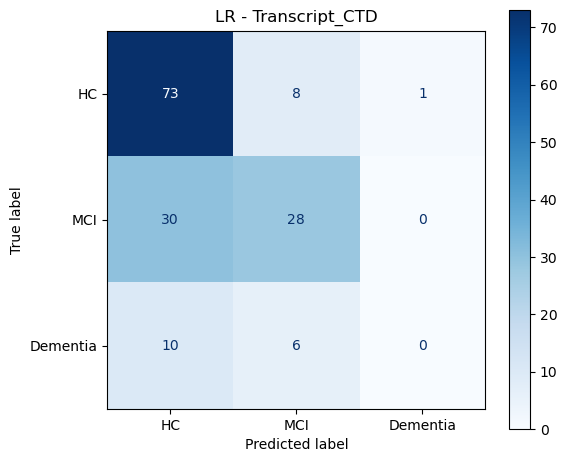


Classification Report:
              precision    recall  f1-score   support

          HC       0.65      0.89      0.75        82
         MCI       0.67      0.48      0.56        58
    Dementia       0.00      0.00      0.00        16

    accuracy                           0.65       156
   macro avg       0.44      0.46      0.44       156
weighted avg       0.59      0.65      0.60       156

Transcript_SFT
Best config: C=0.1, class_weight=balanced


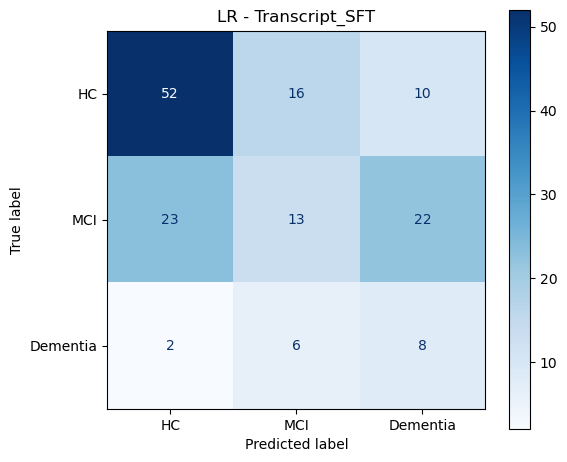


Classification Report:
              precision    recall  f1-score   support

          HC       0.68      0.67      0.67        78
         MCI       0.37      0.22      0.28        58
    Dementia       0.20      0.50      0.29        16

    accuracy                           0.48       152
   macro avg       0.42      0.46      0.41       152
weighted avg       0.51      0.48      0.48       152



In [142]:
# best model for each transcript type
for transcript_col in TRANSCRIPT_COLS:
    df = features_by_transcript[transcript_col]
    config = best_configs[transcript_col]
    
    print(f"{transcript_col}")
    print(f"Best config: C={config['C']}, class_weight={config['class_weight']}")
 
    
    y_true, y_pred = evaluate_best_model(df, transcript_col, config)
    

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title(f"LR - {transcript_col}")
    plt.tight_layout()
    plt.savefig(f"results/lr_cm_{transcript_col}.png", dpi=150)
    plt.show()
    

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))


## Feature Importance

Features most important for classification

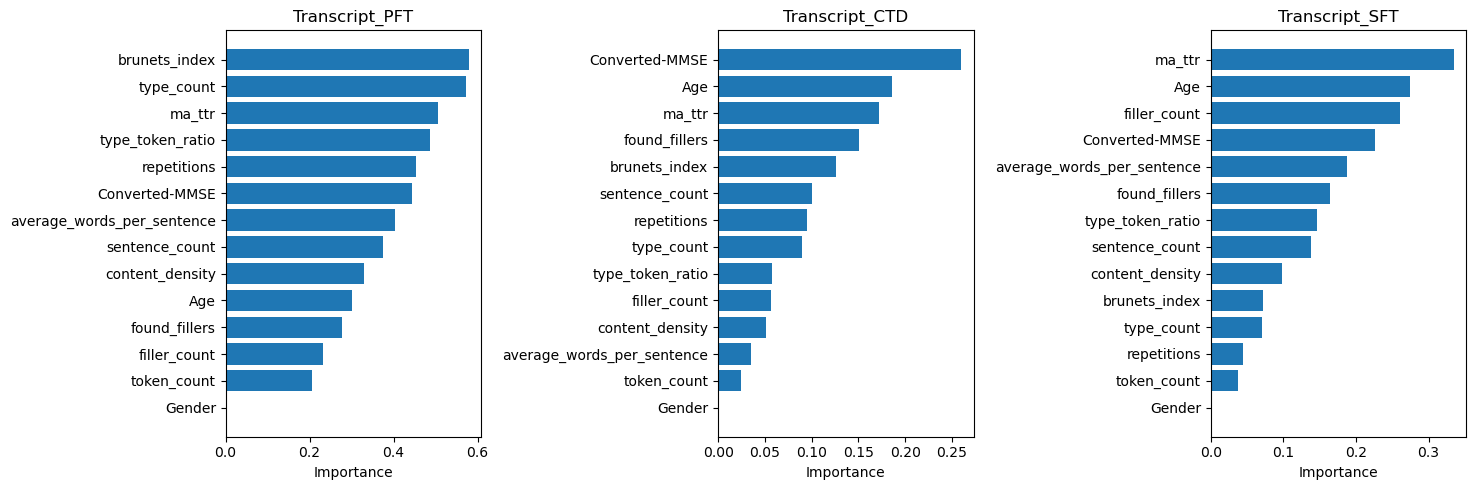

In [143]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, transcript_col in zip(axes, TRANSCRIPT_COLS):
    df = features_by_transcript[transcript_col]
    config = best_configs[transcript_col]
    
    X = np.nan_to_num(df[FEATURE_COLS].values, nan=0.0)
    y = df["Label"].values
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    model = LogisticRegression(
        C=config["C"], class_weight=config["class_weight"],
        max_iter=1000, random_state=42
    )
    model.fit(X_scaled, y)
    
    # Average absolute coefficients across classes
    importance = np.abs(model.coef_).mean(axis=0)
    sorted_idx = np.argsort(importance)
    
    ax.barh([FEATURE_COLS[i] for i in sorted_idx], importance[sorted_idx])
    ax.set_xlabel("Importance")
    ax.set_title(transcript_col)

plt.tight_layout()
plt.savefig("results/lr_feature_importance.png", dpi=150)
plt.show()


## Summary

Compare LR with Feature Engineering results across transcript types.



Best Results per Transcript Type:
    transcript    C class_weight  mean_accuracy  mean_macro_f1
Transcript_CTD  0.1         None       0.646774       0.430488
Transcript_SFT  0.1     balanced       0.480430       0.407854
Transcript_PFT 10.0         None       0.579234       0.405351


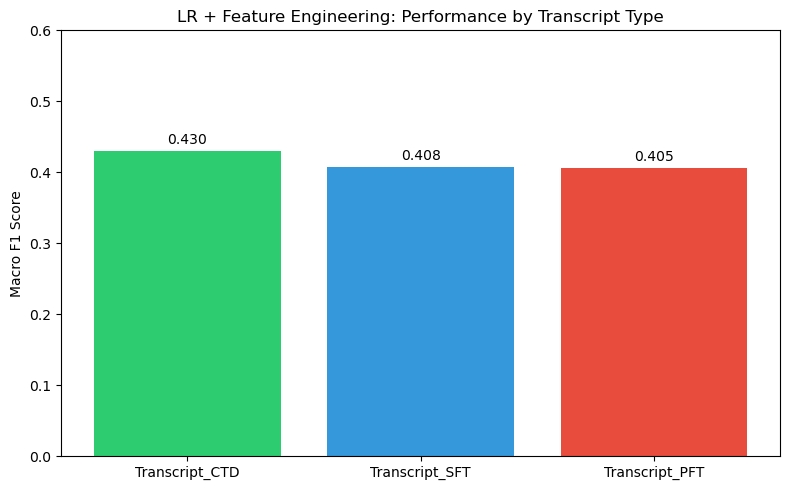


Best transcript type: Transcript_CTD
Best macro F1: 0.4305


In [144]:
summary = results_df.loc[
    results_df.groupby("transcript")["mean_macro_f1"].idxmax()
][["transcript", "C", "class_weight", "mean_accuracy", "mean_macro_f1"]]

summary = summary.sort_values("mean_macro_f1", ascending=False)
print("\nBest Results per Transcript Type:")
print(summary.to_string(index=False))


fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(summary))
colors = ["#2ecc71", "#3498db", "#e74c3c"]
ax.bar(x, summary["mean_macro_f1"], color=colors)
ax.set_xticks(x)
ax.set_xticklabels(summary["transcript"])
ax.set_ylabel("Macro F1 Score")
ax.set_title("LR + Feature Engineering: Performance by Transcript Type")
ax.set_ylim(0, 0.6)
for i, v in enumerate(summary["mean_macro_f1"]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.savefig("results/lr_feature_eng_comparison.png", dpi=150)
plt.show()

print(f"\nBest transcript type: {summary.iloc[0]['transcript']}")
print(f"Best macro F1: {summary.iloc[0]['mean_macro_f1']:.4f}")


### Save Results


In [145]:
# Save results
results_df.to_csv("results/lr_feature_eng_grid_search.csv", index=False)
summary.to_csv("results/lr_feature_eng_best.csv", index=False)
